# From Perceptron to Deep Learning

## Project: Student Exam Success Predictor

**A hands-on journey through Artificial Neural Networks(ANN)**
In this notebook we build a real, relatable machine-learning project - predicting whether a sutdent will **pass or fail** an exam based on their habits(study hours, sleep attendace, previous scores, etc.) - and use it to learn every core Deep learning concept

| **#** | **Concept** | **Where we cover it** |
| --- | --- | --- |
| 1 | Perceptron | Part 1 |
| 2 | Activation Functions | Part 2 |
| 3 | Architecture: Layers, Weights, Biases  | Part 3 |
| 4 | Forward & Backpropagation | Part 4 |
| 5 | Optimization: Gradient Descent & Adam | Part 5 |
| 6 | The Capstone Project(Keras) | Part 6 |
| 7 | Overfitting | Part 7 |
| 8 | Regularization: Dropout, BatchNorm, Early Stopping | Part 8 |

Why this project? Every student intuitively understands study more, sleep well, attend class->better result that makes it the perfect project to see how neural networks learn the same relationship from data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8,4)


In [4]:
class Perceptron:
    def __init__(self, n_features, lr = 0.1, epochs = 20):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
    
    def step(self, z):
        return np.where(z >= 0, 1, 0)
    
    def predict(self, X):
        return self.step(X @ self.w + self.b)
    
    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.lr * (target - self.step(xi @ self.w + self.b))
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            if errors == 0:
                print(f'Converged at epoch {epoch}')
                break
        return self

xToy = np.array([[0,0], [0,1], [1,0], [1,1]])
yToy = np.array([0,0,0,1])

p = Perceptron(n_features=2).fit(xToy, yToy)
print('Learned weights:', p.w, 'bias', round(p.b, 3))
print('Predictions:', p.predict(xToy), '| Truth:', yToy)


Converged at epoch 3
Learned weights: [0.2 0.1] bias -0.2
Predictions: [0 0 0 1] | Truth: [0 0 0 1]


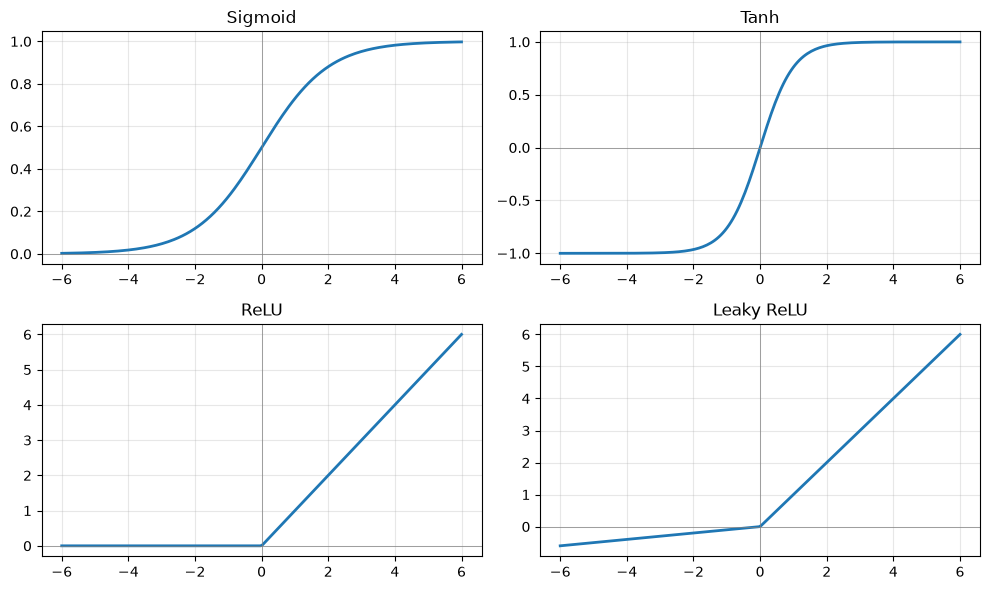

In [5]:
def sigmoid(z):     return 1 / (1 + np.exp(-z))
def tanh(z):        return np.tanh(z)
def relu(z):        return np.maximum(0, z)
def leaky_relu(z): return np.where(z > 0, z, 0.1 * z)

z = np.linspace(-6, 6, 200)
funcs = {'Sigmoid': sigmoid, 'Tanh': tanh, 'ReLU': relu, 'Leaky ReLU': leaky_relu}

fig, axes = plt.subplots(2,2,figsize=(10,6))
for ax, (name, f) in zip(axes.ravel(), funcs.items()):
    ax.plot(z, f(z), lw = 2)
    ax.axhline(0, color = 'gray', lw = 0.5)
    ax.axvline(0, color = 'gray', lw = 0.5)
    ax.set_title(name)
    ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

In [6]:
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
print('Raw Scores : ', scores)
print('Softmax    : ', np.round(softmax(scores), 3), '(sums to ', round(softmax(scores).sum(), 3), ')')

Raw Scores :  [2.  1.  0.1]
Softmax    :  [0.659 0.242 0.099] (sums to  1.0 )


In [7]:
layers = [4,5,1]
total = 0

for i in range(len(layers) - 1):
    n_in, n_out = layers[i], layers[i+1]
    w_count = n_in * n_out
    b_count = n_out
    total += w_count + b_count
    print(f'Layer {i} -> {i+1}: weights = {w_count:2d} biases = {b_count:2d}')
print(f'Total trainable parameters: {total}')

Layer 0 -> 1: weights = 20 biases =  5
Layer 1 -> 2: weights =  5 biases =  1
Total trainable parameters: 31


# Part 4 - Forward & Backpropogation

this is the heart of learning. Two passes per training step:
1. **Forward pass:** push inputs thruogh the layers to get a prediciton
2. **Backward pass(backpropogation):** measure the erroe(loss), then use the chain rule to compute how much each weight contributed to that error (the gradient), and nudge weights to reduce it.

To make it crystal clear, we build a 2 layer neural network from scratch in pure NumPy 

In [8]:
x = np.array([[0,0], [0,1], [1,0], [1,1]], dtype = float)
y = np.array([[0], [1], [1], [0]], dtype = float)

def sig(z): return 1 / (1 + np.exp(-z))
def dsig(a): return a * (1 - a)

n_in, n_hidden, n_out = 2, 4, 1
W1 = np.random.randn(n_in, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_out) * 0.5
b2 = np.zeros((1, n_out))

lr = 0.5
losses = []
for epoch in range(5000):
    z1 = x @ W1 + b1
    a1 = sig(z1)
    z2 = a1 @ W2 + b2
    a2 = sig(z2)

    loss = np.mean((a2 - y) ** 2)
    losses.append(loss)

    d_a2 = 2 * (a2 - y) / len(y)
    d_z2 = d_a2 * dsig(a2)
    d_W2 = a1.T @ d_z2
    d_b2 = d_z2.sum(axis = 0, keepdims = True)

    d_a1 = d_z2 @ W2.T
    d_z1 = d_a1 * dsig(a1)
    d_W1 = x.T @ d_z1
    d_b1 = d_z1.sum(axis = 0, keepdims = True)
    
    W2 -= lr * d_W2
    b2 -= lr * d_b2
    W1 -= lr * d_W1
    b1 -= lr * d_b1

print('Final loss:', round(losses[-1], 5))
print('Predictions:', np.round(a2.ravel(), 2), '| Truth:', y.ravel())

Final loss: 0.00266
Predictions: [0.06 0.95 0.95 0.05] | Truth: [0. 1. 1. 0.]


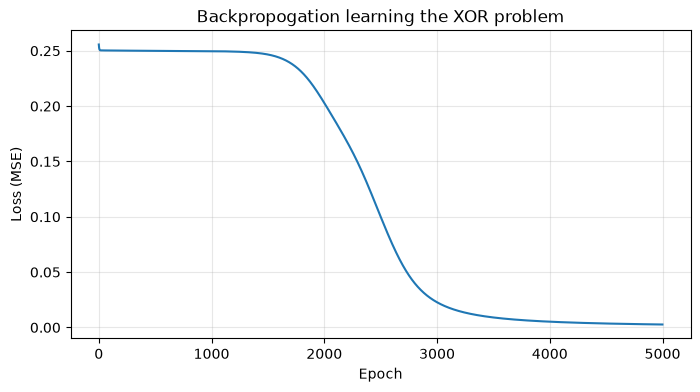

In [9]:
plt.plot(losses)
plt.title('Backpropogation learning the XOR problem')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(alpha = 0.3)
plt.show()

# Part 5 - Optimization: Gradient Descent & Adam

#### An **optimizer** decides how to update weights using the gradients from back prop. Think of it as walking downhill on the loss the lowest point (minimum error).
- **Gradient Descent (GD):** step in the opposite direction of the gradient. **Step size = Learning rate**
    - Too small -> slow. Too large -> overshoots/diverges
- **Adam** (adaptive moment estimation): combines momentum (remembers past gradients) with **per-parameter adaptive learning rates**. It usually converges faster and is the modern default. 
Let's watch both minimize a simple bowl shaped function f(x) = x<sup>2</sup> :

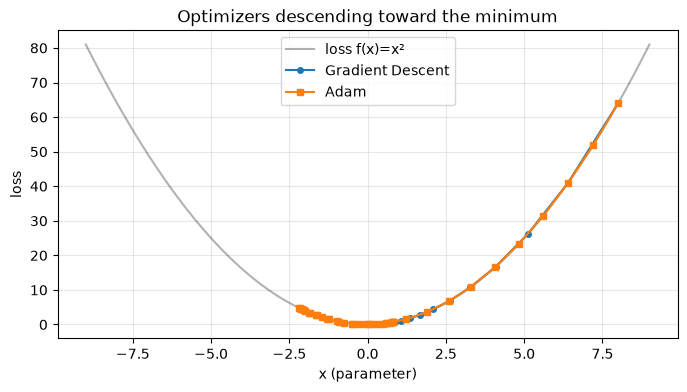

GD final x: 0.0011
Adam final x: 0.8063


In [15]:
def grad(x): return 2 * x

xGd, lr = 8.0, 0.1
pathGd = [xGd]
for _ in range(40):
    xGd -= lr * grad(xGd)
    pathGd.append(xGd)

xAdam, lr = 8.0, 0.8 
m, v, b1, b2, eps = 0, 0, 0.9, 0.999, 1e-8
pathAdam = [xAdam]
for t in range(1, 41):
    g = grad(xAdam)
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g**2
    mHat = m / (1 - b1**t)
    vHat = v / (1 - b2**t)
    xAdam -= lr * mHat / (np.sqrt(vHat) + eps)
    pathAdam.append(xAdam)

xs = np.linspace(-9, 9, 100)
plt.plot(xs, xs**2, 'k-', alpha=0.3, label='loss f(x)=x\u00b2')
plt.plot(pathGd, [p**2 for p in pathGd], 'o-', ms=4, label='Gradient Descent')
plt.plot(pathAdam, [p**2 for p in pathAdam], 's-', ms=4, label='Adam')
plt.legend()
plt.title('Optimizers descending toward the minimum')
plt.xlabel('x (parameter)')
plt.ylabel('loss')
plt.grid(alpha=0.3)
plt.show()
print('GD final x:', round(pathGd[-1],4))
print('Adam final x:', round(pathAdam[-1],4))


# Part 6 - The Capstone Project: Student Exam Success Predictor 

Now we bring everything together on a realistic dataset using **Keras/TensorFlow**

### The Data
We generate a synthetic-but-realistic dataset of 2000 students with features: `study_hours`, `sleep_hours`, `attendence_%`, `previous_score`, `assignment_score`. A student **passes (1)** when the combination of good habits is high enough (plus some real-world noise).

This mirros any real tabular ML problem: churn prediction, loan approval, medical diagnosis, etc.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

n           = 2000
rng         = np.random.default_rng(42)
study       = rng.uniform(0,10,n)
sleep       = rng.uniform(3,9,n)
attendance  = rng.uniform(40,100,n)
prev_score  = rng.uniform(30,100,n)
assign      = rng.integers(0,11,n)

# Hidden 'true' relationship + noise

score = (0.9*study + 0.4*sleep + 0.05*attendance + 0.04*prev_score + 0.3*assign + rng.normal(0, 1.5, n))
y = (score > np.median(score)).astype(int)

df = pd.DataFrame({
    'study_hours'       : study, 
    'sleep_hours'       : sleep, 
    'attendance'        : attendance,
    'prev_score'        : prev_score,
    'assignments_done'  : assign,
    'passed'            : y
})

print(df.head())
print('\n Pass Rate:', round(df.passed.mean(), 3))

   study_hours  sleep_hours  attendance  prev_score  assignments_done  passed
0     7.739560     8.056392   82.965998   61.883346                10       1
1     4.388784     5.678337   61.426936   38.320059                 6       1
2     8.585979     8.717851   91.112071   69.842140                 0       1
3     6.973680     6.904768   54.458630   40.950018                 9       1
4     0.941773     3.695393   72.303609   34.267083                10       0

 Pass Rate: 0.5


In [18]:
x = df.drop(columns='passed').values
y = df['passed'].values

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(xTrain)
xTrain = scaler.transform(xTrain)
xTest  = scaler.transform(xTest)
print('Train:', xTrain.shape, 'Test:', xTest.shape)


Train: (1600, 5) Test: (400, 5)


In [27]:
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

def build_model(regularized=False):
    model = keras.Sequential(name='ExamPredictor')
    model.add(keras.Input(shape=(xTrain.shape[1],)))
    model.add(layers.Dense(32, activation='relu'))
    if regularized:
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(16, activation='relu'))
    if regularized:
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer     ='adam',
                  loss          ='binary_crossentropy',
                  metrics       =['accuracy'])
    return model
build_model().summary()

Model: "ExamPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

# Part 7 - Overfitting

**Overfitting** = the model memorizes the training data (including noise) instead of learning the general pattern. Symptom: **training accuracy keeps rising while validation accuracy stalls or drops.**

To provoke overfitting, we train a plain (unregularized) network for many epochs and watch gap grow.

In [28]:
plain = build_model(regularized=False)
hist_plain = plain.fit(xTrain, yTrain,
                       validation_split=0.2,
                       epochs=150, batch_size=32, verbose=0)
print('Done. Final train acc:', round(hist_plain.history['accuracy'][-1],3), '| Val acc:', round(hist_plain.history['val_accuracy'][-1],3))


Done. Final train acc: 0.895 | Val acc: 0.856


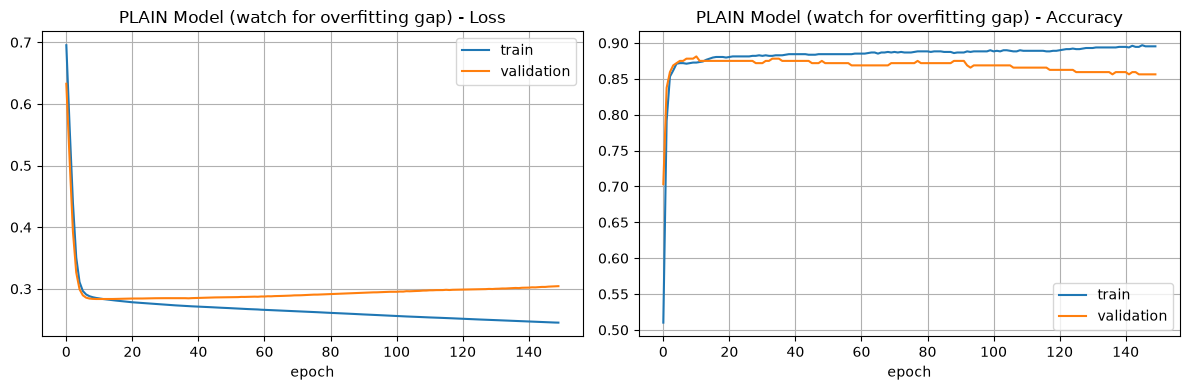

In [34]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history['loss'], label='train')
    ax[0].plot(hist.history['val_loss'], label='validation')
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('epoch')
    ax[0].legend()
    ax[0].grid([8,4])
    ax[1].plot(hist.history['accuracy'], label='train')
    ax[1].plot(hist.history['val_accuracy'], label='validation')
    ax[1].set_title(f'{title} - Accuracy')
    ax[1].set_xlabel('epoch')
    ax[1].legend()
    ax[1].grid([8,4])
    plt.tight_layout()
    plt.show()

plot_history(hist_plain, 'PLAIN Model (watch for overfitting gap)')

# **Part 8 - Regularization**: Dropout, Batch Normalization & Early Stopping

| **Technique** | **What it does** |
| --- | --- | 
| Dropout  | randmly switches off a fraction of neurons each step |
| Batch Normalization | Normilizes each layer's inputs per mini-batch|
| Early stopping | Halts training when validation stops improving|

Training stopped at epock: 57


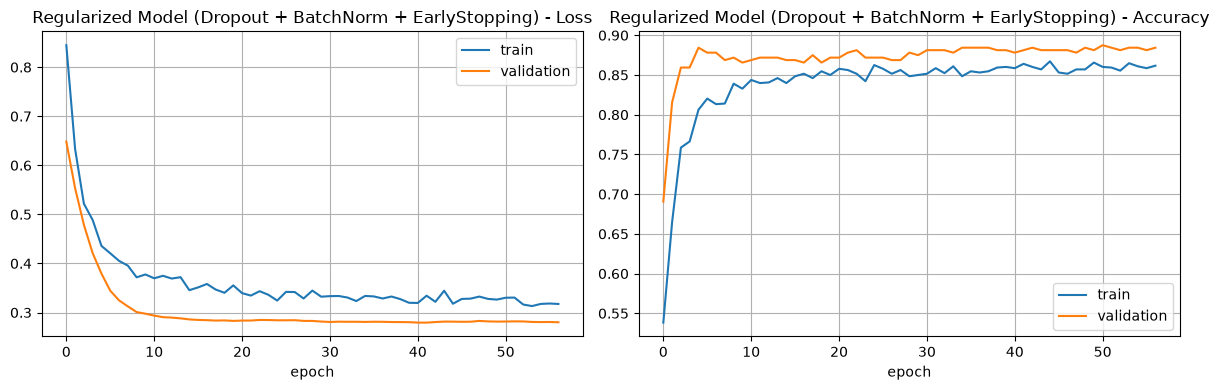

In [ ]:
earlyStop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,                    # wait for 15 epochs for improvement
    restore_best_weights=True)      # roll back to the best model

reg = build_model(regularized=True)
hist_reg = reg.fit(xTrain, yTrain,
                   validation_split = 0.2,
                   epochs = 150, batch_size = 32,
                   callbacks = [earlyStop], verbose = 0)

print(f'Training stopped at epoch: {len(hist_reg.history['loss'])}')
plot_history(hist_reg, 'Regularized Model (Dropout + BatchNorm + EarlyStopping)')

Plain model test accuracy: 0.825
Regularized model test accuracy: 0.850


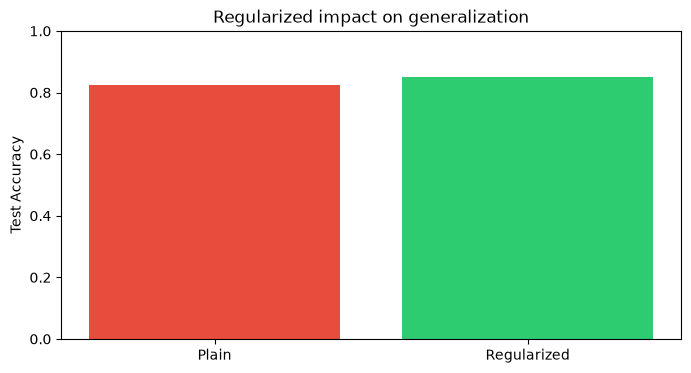

In [39]:
plain_acc = plain.evaluate(xTest, yTest, verbose = 0)[1]
reg_acc = reg.evaluate(xTest, yTest, verbose = 0)[1]

print(f'Plain model test accuracy: {plain_acc:.3f}')
print(f'Regularized model test accuracy: {reg_acc:.3f}')

plt.bar(['Plain', 'Regularized'], [plain_acc, reg_acc], color = ['#e74c3c', '#2ecc71'])
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.title('Regularized impact on generalization')
plt.show()

